In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os

plt.style.use('../libs/my_style.mplstyle')

#root = Path('/mnt/e/Sasaki/MTsingleBeads')
root = Path('/Volumes/My Passport/Sasaki/MTsingleBeads')

path0 = root / "20260121" / 'exp_crop1'
path1 = root / "20260121" / 'beads_trans_crop_crop'
path2 = root / "20260122" / "exp"
path3 = root / "20260122" / 'exp001'

path_list = [path0, path1, path2, path3]

def load_metrics(path_list, file_name='GFP_flows_metrics.h5'):
    all_se = []
    all_ae = []

    for path in path_list:
        with h5py.File(path / file_name, 'r') as f:
            speed_err = f['speed_error'][:]
            angle_err = f['orientation_error_deg'][:]
            all_se.extend(speed_err)
            all_ae.extend(angle_err)

    return np.array(all_se), np.array(all_ae)

save_path = Path("/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures/DLOF_err")

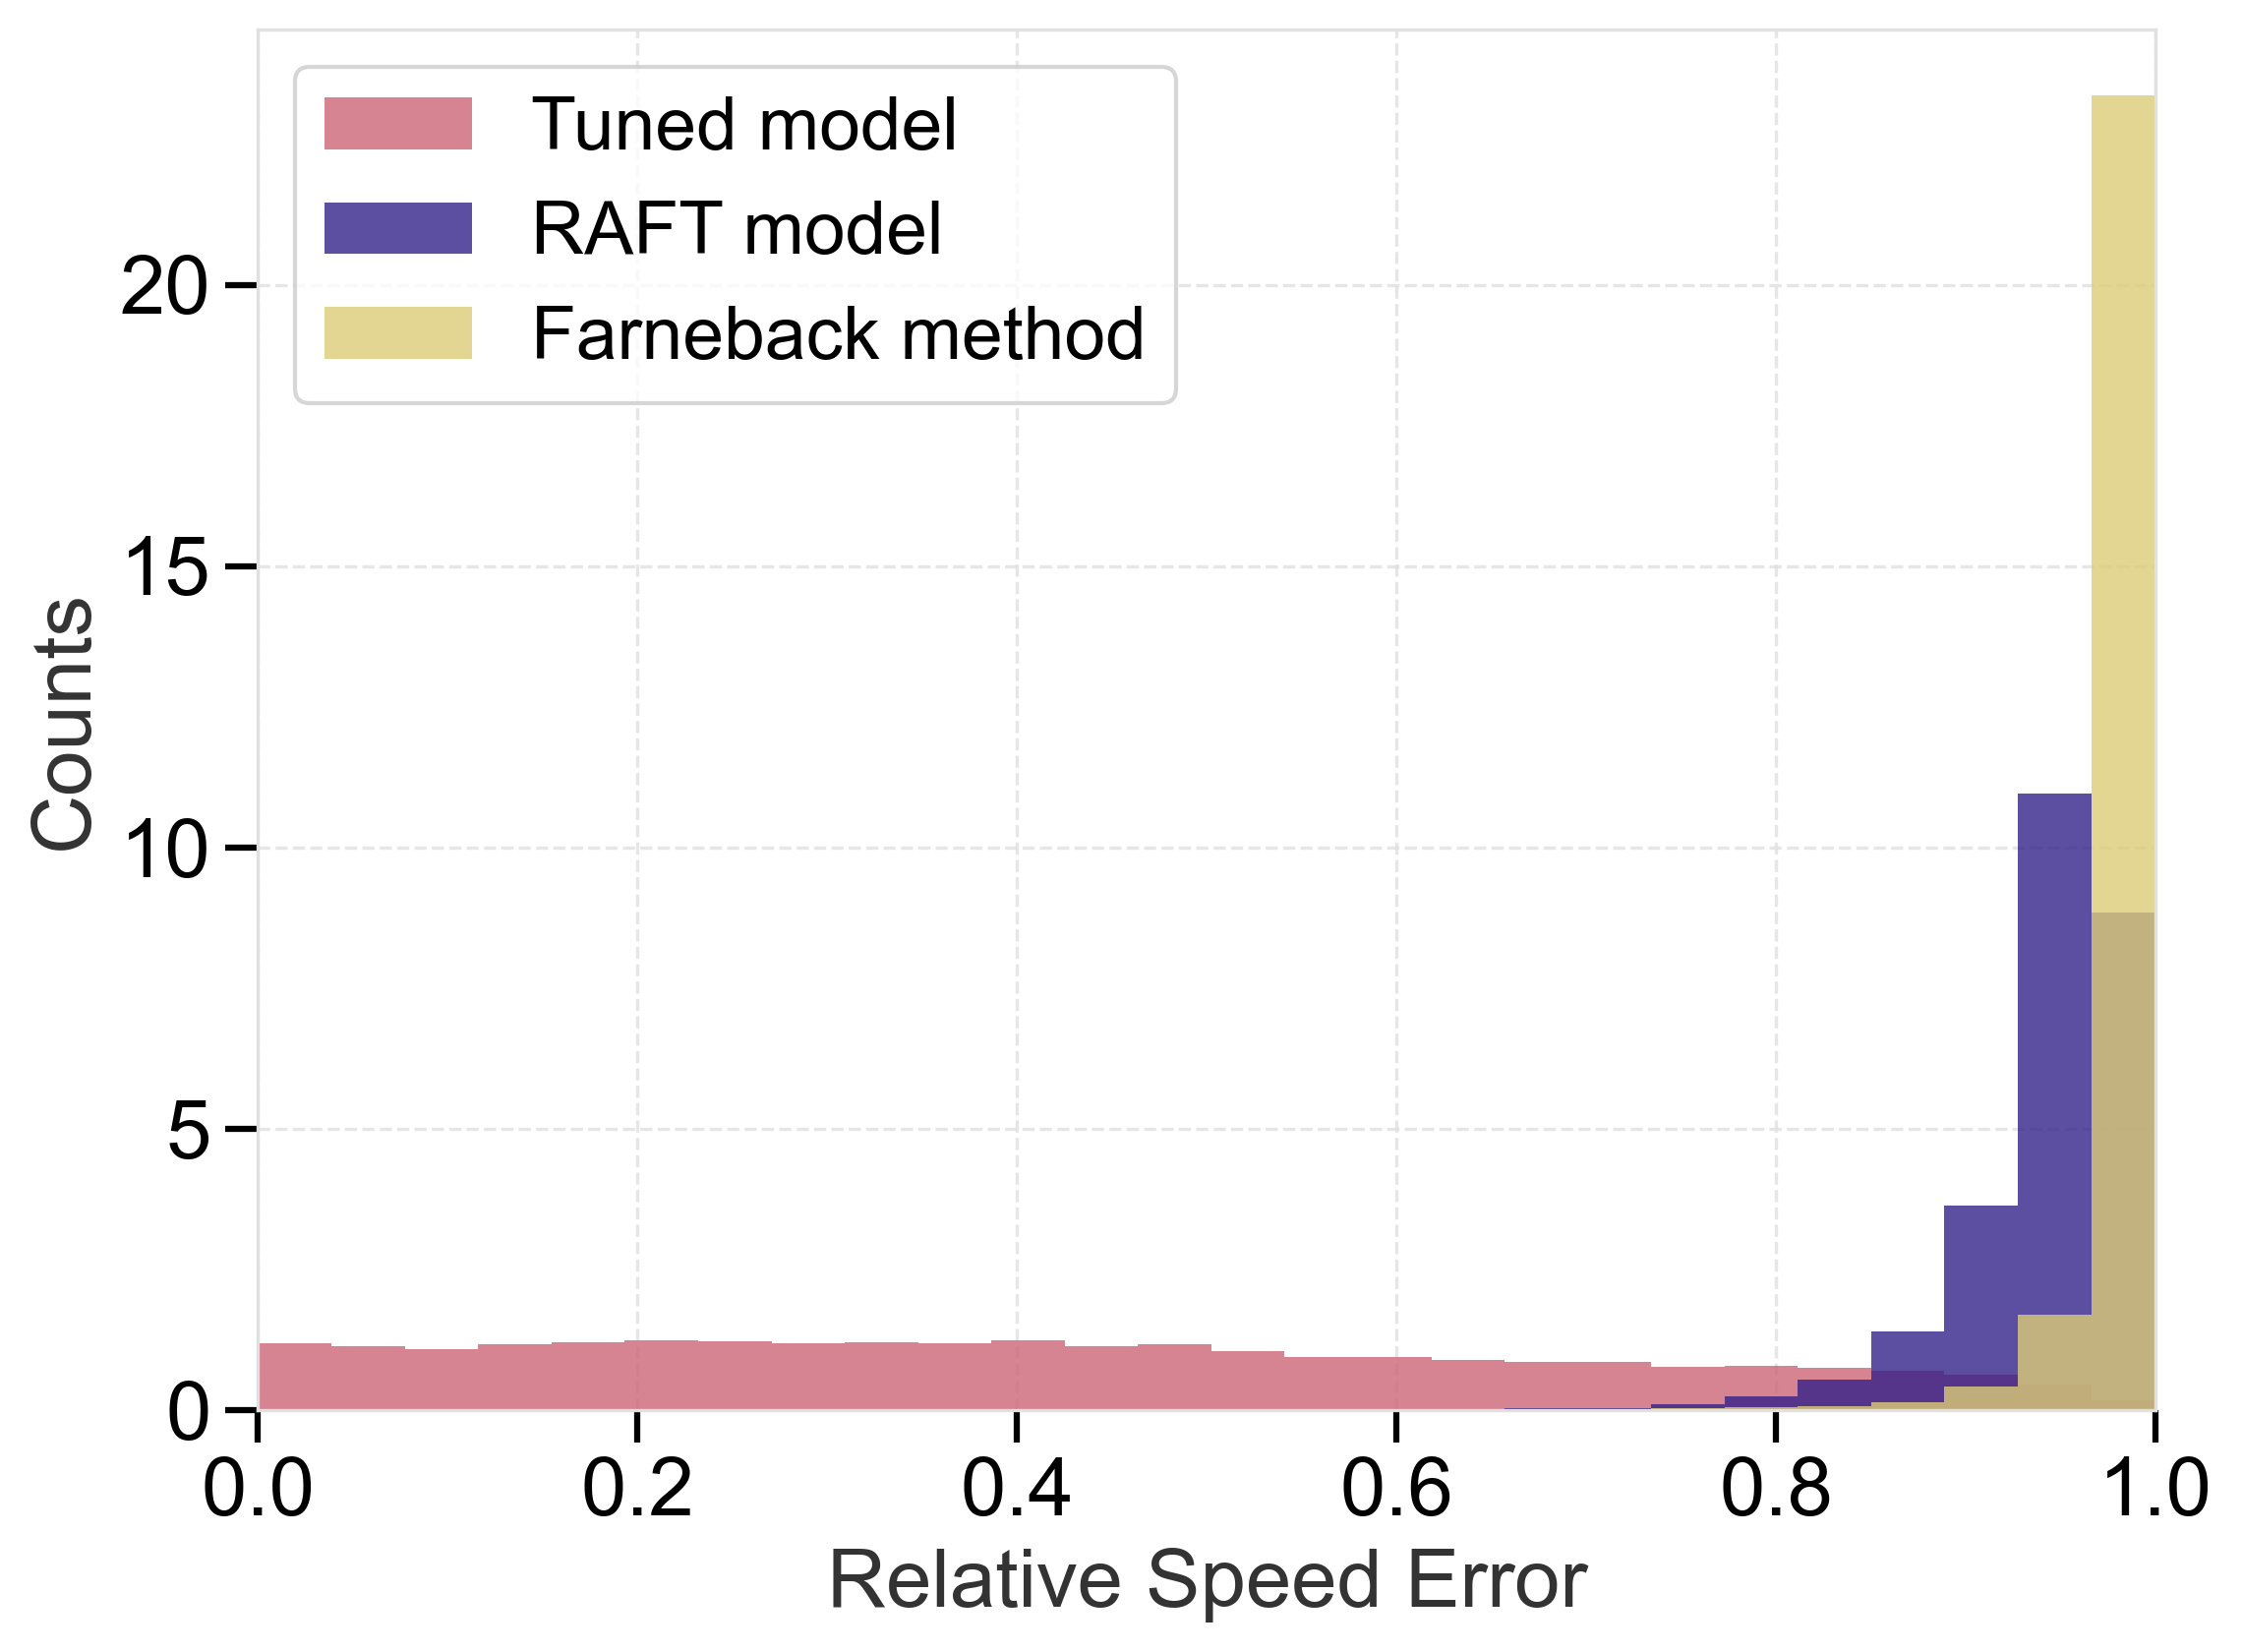

In [9]:
good_se, good_ae = load_metrics(path_list, file_name='good_eval.h5')
bad_se, bad_ae = load_metrics(path_list, file_name='bad_eval.h5')
fb_se, fb_ae = load_metrics(path_list, file_name='Farneback_metrics.h5')

fig, ax = plt.subplots()
edge = np.histogram_bin_edges(good_se, bins="sqrt")
ax.hist(good_se, bins=edge, density=True, alpha = 0.8, label = 'Tuned model')
ax.hist(bad_se, bins=edge, density=True, alpha = 0.8, label = 'RAFT model')
ax.hist(fb_se, bins=edge, density=True, alpha = 0.8, label = 'Farneback method')
ax.set_xlim(0, 1)
ax.set_xlabel("Relative Speed Error")
ax.set_ylabel("Counts")
ax.legend()
plt.show()

fig.savefig(save_path / 'RSE.png')
fig.savefig(save_path / 'RSE.pdf')

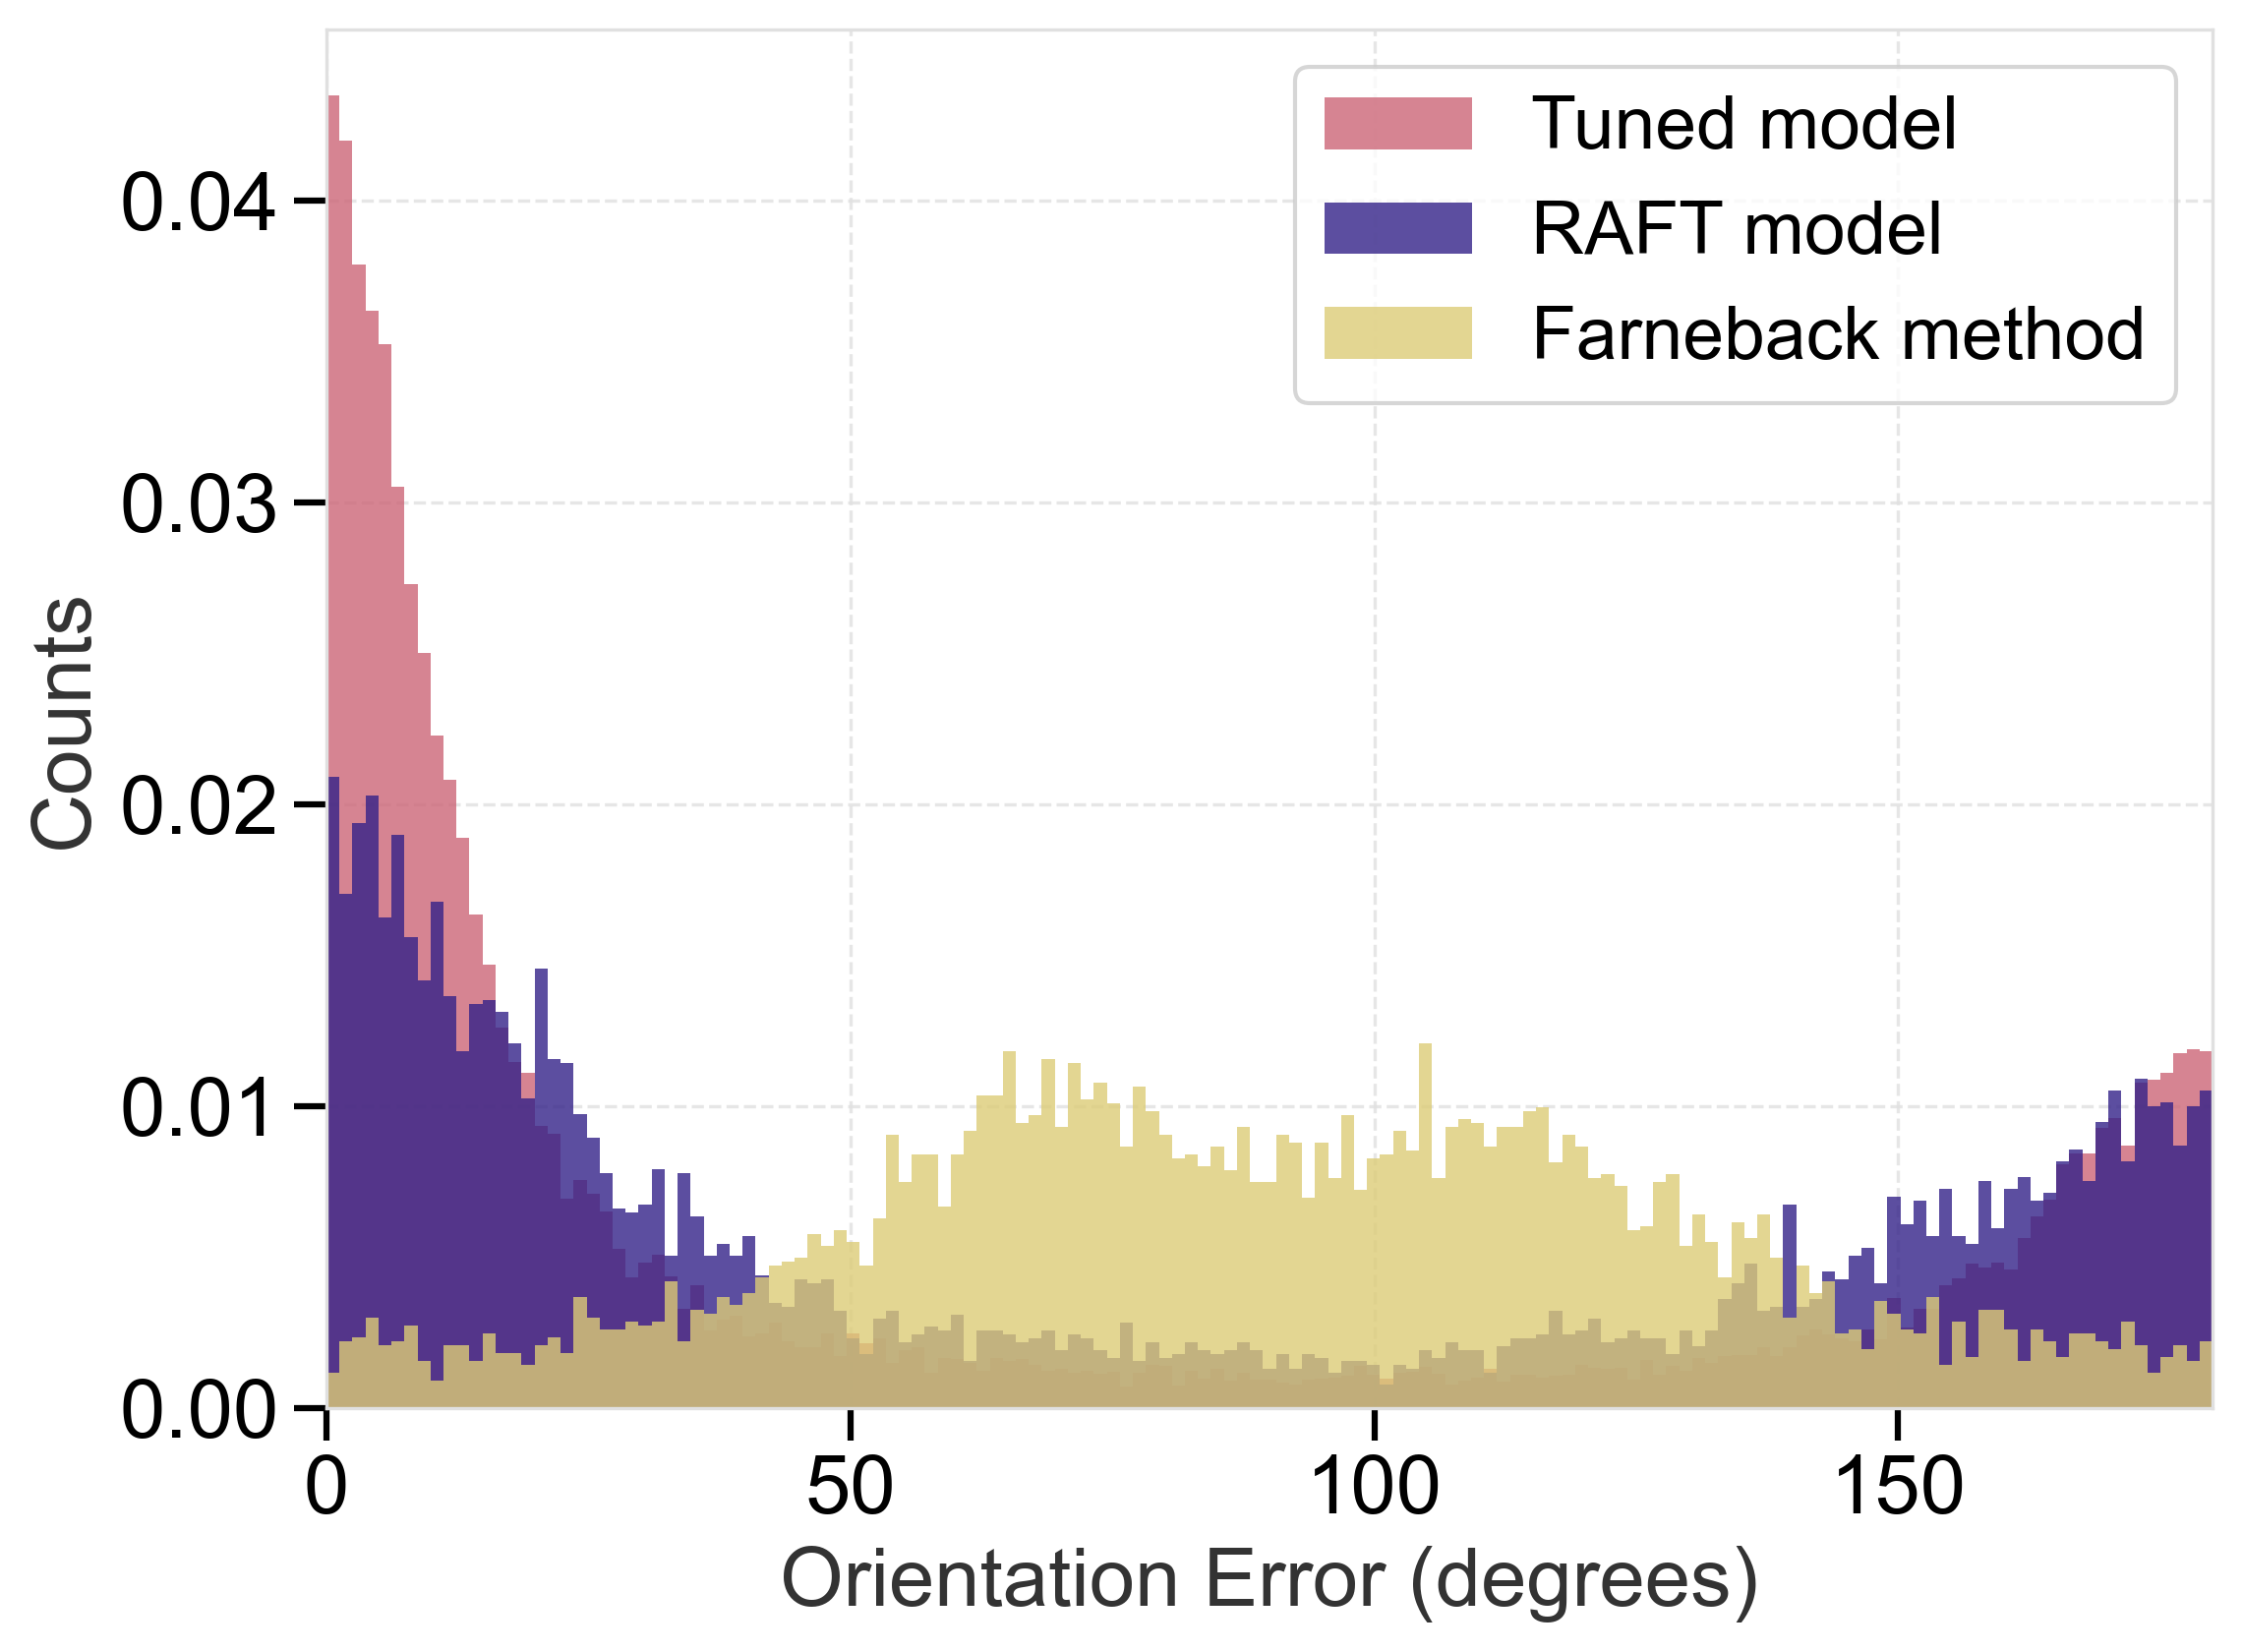

In [8]:
fig, ax = plt.subplots()
edge = np.histogram_bin_edges(good_ae, bins="sqrt")
ax.hist(good_ae, bins=edge, density=True, alpha = 0.8, label = 'Tuned model')
ax.hist(bad_ae, bins=edge, density=True, alpha = 0.8, label = 'RAFT model')
ax.hist(fb_ae, bins=edge, density=True, alpha = 0.8, label = 'Farneback method')
ax.set_xlim(0, 180)
ax.set_xlabel("Orientation Error (degrees)")
ax.set_ylabel("Counts")
ax.legend()
plt.show()

fig.savefig(save_path / 'OE.png')
fig.savefig(save_path / 'OE.pdf')

In [11]:
print(good_ae.shape[0], bad_ae.shape[0], fb_ae.shape[0])

20978 6193 6127


In [ ]:
h5_path = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/Farneback.h5'


def load_flows(h5_path, file_name):
    with h5py.File(h5_path / file_name, 'r') as h5f:
        if 'flows' not in h5f:
            raise KeyError(f"HDF5ファイル内に 'flows' データセットが見つかりません。")
            
        flows = h5f['flows']  # Shape: (T-1, 2, H, W)
        num_frames = flows.shape[0]
        C, H, W = flows.shape[1:]

        print(f"{h5_path}/{file_name}, Number of flow frames: {num_frames}, Channel:{C}, Height: {H}, Width: {W}")

for path in path_list:
    load_flows(path, file_name='GFP_flows.h5')
    load_flows(path, file_name='GFP_flows_bad.h5')
    #load_flows(path, file_name='Farneback.h5')

/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/GFP_flows.h5, Number of flow frames: 490, Channel:2, Height: 2160, Width: 2560
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/GFP_flows_bad.h5, Number of flow frames: 490, Channel:2, Height: 2160, Width: 2560
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/Farneback.h5, Number of flow frames: 490, Channel:2160, Height: 2560, Width: 2
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/GFP_flows.h5, Number of flow frames: 270, Channel:2, Height: 2160, Width: 2560
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/GFP_flows_bad.h5, Number of flow frames: 270, Channel:2, Height: 2160, Width: 2560
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/Farneback.h5, Number of flow frames: 270, Channel:2160, Height: 2560, Width: 2
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/GFP_flows.h5, Number of flow frames: 270, Channel:2, Height: 

In [ ]:
def load_eval(h5_path, file_name):
    with h5py.File(h5_path / file_name, 'r') as h5f:    
        print(f"{h5_path}/{file_name}, Speed Error Shape: {h5f['speed_error'].shape}")
        print(f"{h5_path}/{file_name}, Orientation Error Shape: {h5f['orientation_error_deg'].shape}")

        #print(f"{h5_path}/{file_name}, Number of flow frames: {num_frames}, Channel:{C}, Height: {H}, Width: {W}")

for path in path_list:
    load_eval(path, file_name='good_eval.h5')
    load_eval(path, file_name='bad_eval.h5')

/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/good_eval.h5, Orientation Error Shape: (650,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/bad_eval.h5, Orientation Error Shape: (650,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/good_eval.h5, Orientation Error Shape: (2016,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/bad_eval.h5, Orientation Error Shape: (2016,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/good_eval.h5, Orientation Error Shape: (815,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/bad_eval.h5, Orientation Error Shape: (815,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001/good_eval.h5, Orientation Error Shape: (17497,)
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001/bad_eval.h5, Orientation Error Shape: (2712,)
